# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

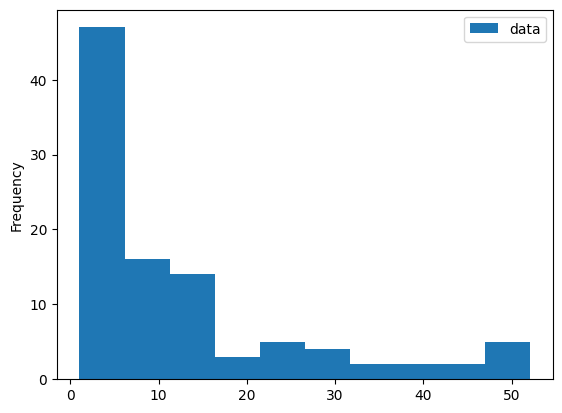

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

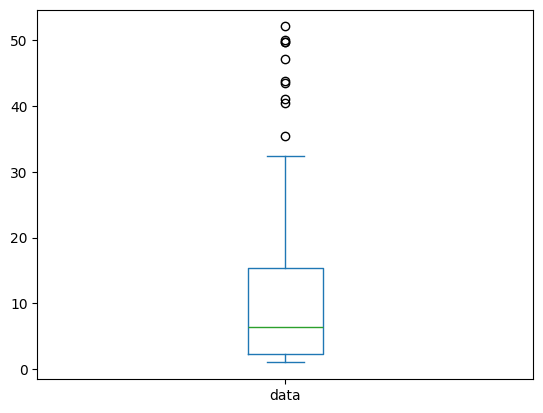

In [3]:
df.plot.box()

Pros and Cons

Histogram:

Pros:
- Shows the shape of the distribution (e.g., skewness, clusters).
- Can see the spread and frequency of prices across ranges.

Cons:
- Harder to quickly identify specific percentiles (like the 75th or 90th).
- Bin width choices affect interpretation and can hide details.

Boxplot:

Pros:
- Clearly shows median, quartiles, and outliers.
- Highlights extreme values, which is important for expensive drugs.
- Easy to compare multiple distributions side by side.

Cons:
- Does not show the detailed shape of the distribution (e.g., whether it’s multimodal).
- Less intuitive for seeing frequency counts or clusters.

Understanding how expensive drugs compare in context, I would choose the boxplot as the primary visualization. It quickly communicates the median, upper quartiles, and outliers, which is exactly what an administrator cares about. The histogram can be supplementary to show overall distribution if needed.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [1]:
# Import data from Kaggle

import os
import pandas as pd
import kagglehub

# 1. Download the dataset from Kaggle
dataset_path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")
print("Dataset downloaded to:", dataset_path)

# 2. Find the CSV file inside the extracted folder
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the dataset folder!")
csv_file = os.path.join(dataset_path, csv_files[0])
print("CSV file detected:", csv_file)

# 3. Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file, encoding='ISO-8859-1')

# 4. Quick check
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1
CSV file detected: /home/codespace/.cache/kagglehub/datasets/ammaraahmad/us-ecommerce-record-2020/versions/1/US  E-commerce records 2020.csv
Dataset loaded successfully!
Shape: (3312, 19)
  Order Date  Row ID        Order ID       Ship Mode Customer ID      Segment  \
0   01-01-20     849  CA-2017-107503  Standard Class    GA-14725     Consumer   
1   01-01-20    4010  CA-2017-144463  Standard Class    SC-20725     Consumer   
2   01-01-20    6683  CA-2017-154466     First Class    DP-13390  Home Office   
3   01-01-20    8070  CA-2017-151750  Standard Class    JM-15250     Consumer   
4   01-01-20    8071  CA-2017-151750  Standard Class    JM-15250     Consumer   

         Country         City       State  Postal Code   Region  \
0  United States       Lorain        Ohio        44052     East   
1  United States  Los Angeles  California        90036     West   
2  United S

In [2]:
# Quick look at data
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3312 non-null   object 
 1   Row ID        3312 non-null   int64  
 2   Order ID      3312 non-null   object 
 3   Ship Mode     3312 non-null   object 
 4   Customer ID   3312 non-null   object 
 5   Segment       3312 non-null   object 
 6   Country       3312 non-null   object 
 7   City          3312 non-null   object 
 8   State         3312 non-null   object 
 9   Postal Code   3312 non-null   int64  
 10  Region        3312 non-null   object 
 11  Product ID    3312 non-null   object 
 12  Category      3312 non-null   object 
 13  Sub-Category  3312 non-null   object 
 14  Product Name  3312 non-null   object 
 15  Sales         3312 non-null   float64
 16  Quantity      3312 non-null   int64  
 17  Discount      3312 non-null   float64
 18  Profit        3312 non-null 

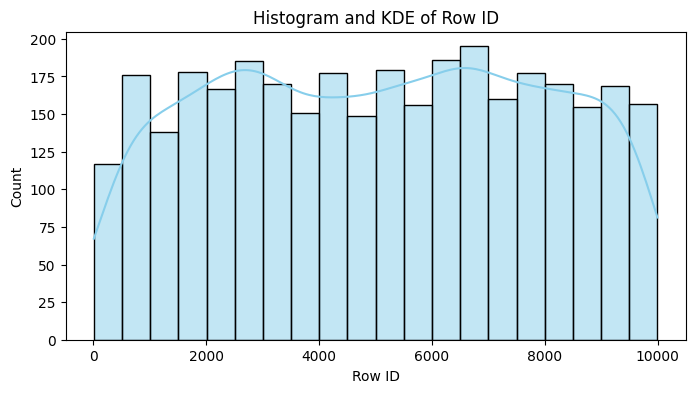

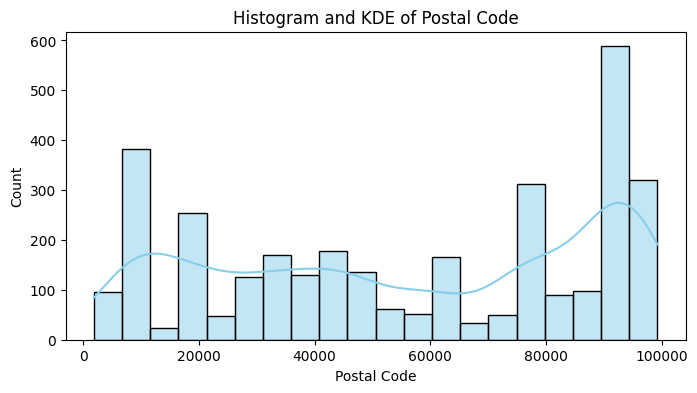

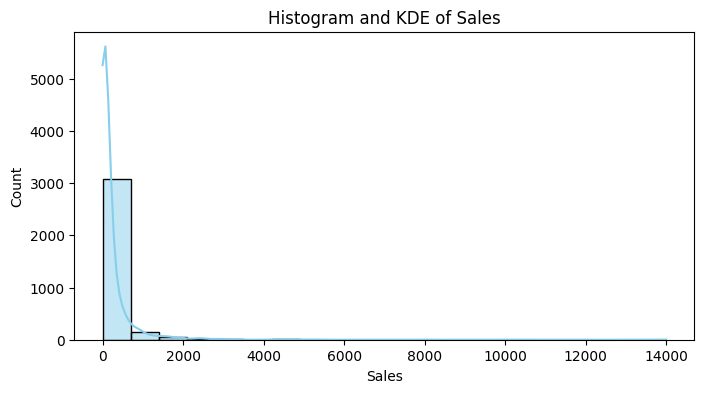

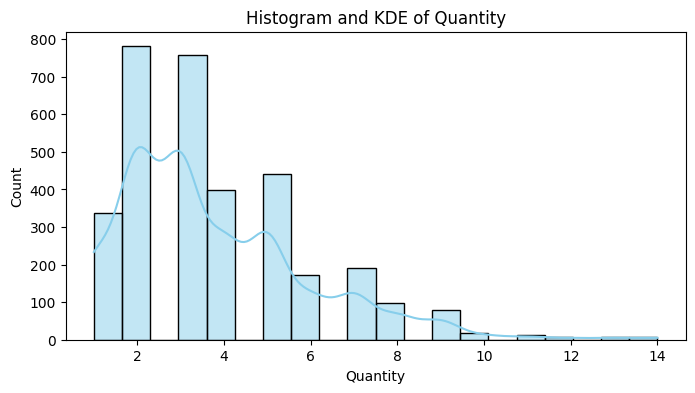

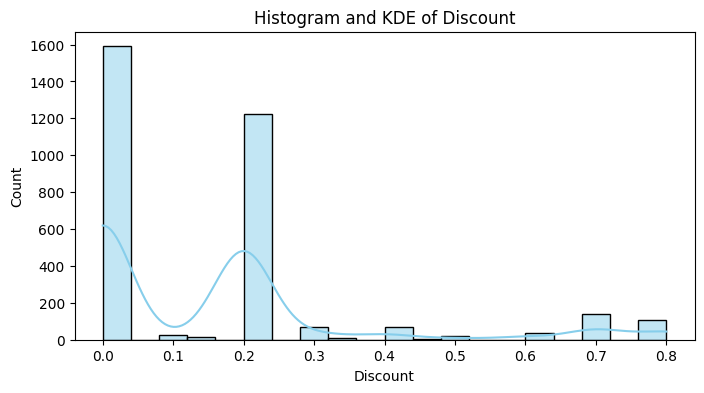

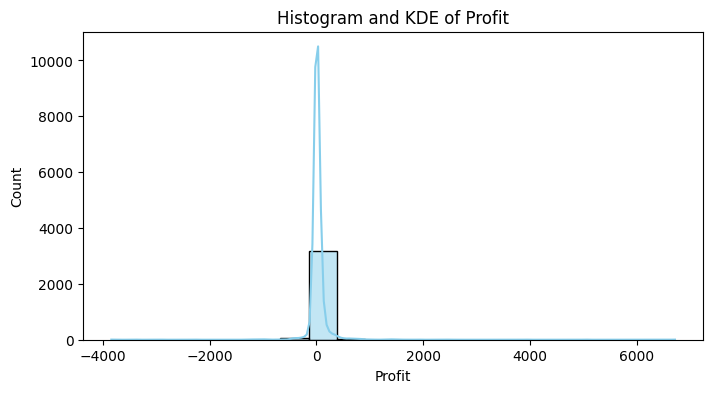

In [3]:
# Histogram and KDE
import matplotlib.pyplot as plt
import seaborn as sns

# For numeric columns
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f"Histogram and KDE of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [4]:
print(df.columns)


Index(['Order Date', 'Row ID', 'Order ID', 'Ship Mode', 'Customer ID',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [5]:
# Violin Plot
# Example: Sleep Hours by Stress Level (categorical)
plt.figure(figsize=(8,5))
sns.violinplot(x='Stress_Level', y='Sleep_Hours', data=df)
plt.title("Violin Plot of Sleep Hours by Stress Level")
plt.show()



ValueError: Could not interpret value `Stress_Level` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x500 with 0 Axes>

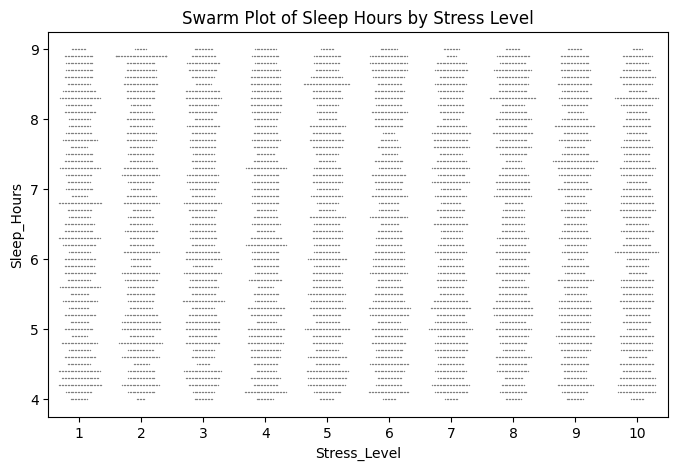

In [9]:
# Swarm Plot
plt.figure(figsize=(8,5))
sns.swarmplot(x='Stress_Level', y='Sleep_Hours', data=df.sample(10000), color='gray', size=1)
plt.title("Swarm Plot of Sleep Hours by Stress Level")
plt.show()

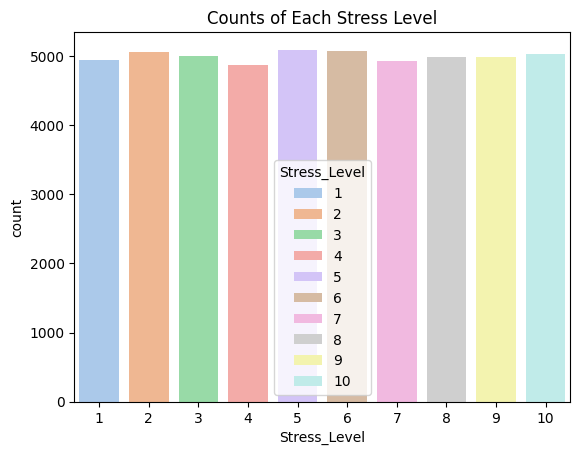

In [12]:
# Bar Plot for Categorical Var: Count of each Stress Level
sns.countplot(x='Stress_Level', data=df, hue='Stress_Level', palette='pastel')
plt.title("Counts of Each Stress Level")
plt.show()

In [13]:
# Mean, median, mode for numeric columns
for col in numeric_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0]
    print(f"{col}: Mean={mean_val:.2f}, Median={median_val:.2f}, Mode={mode_val}")

Age: Mean=39.03, Median=39.00, Mode=54
Daily_Phone_Hours: Mean=6.51, Median=6.50, Mode=6.3
Social_Media_Hours: Mean=4.27, Median=4.30, Mode=5.6
Work_Productivity_Score: Mean=5.50, Median=5.50, Mode=9
Sleep_Hours: Mean=6.50, Median=6.50, Mode=5.0
Stress_Level: Mean=5.50, Median=6.00, Mode=5
App_Usage_Count: Mean=32.44, Median=32.00, Mode=8
Caffeine_Intake_Cups: Mean=3.00, Median=3.00, Mode=2
Weekend_Screen_Time_Hours: Mean=8.01, Median=8.00, Mode=13.2


After analyzing the dataset, several patterns emerge. The numeric features, such as screen time, sleep hours, and stress levels, show varying distribution shapes. Screen time is heavily right-skewed, indicating that most participants spend moderate amounts of time on devices, but a small number have very high usage. Sleep hours appear roughly normal but slightly skewed toward shorter sleep durations, and there are a few outliers where participants report unusually high or low hours. Stress levels, treated as a categorical variable, show a concentration in moderate levels, with fewer participants reporting extreme stress. Grouped visualizations reveal that participants with higher screen time tend to have slightly lower sleep hours, and this trend is more pronounced when comparing stress levels, suggesting a potential relationship between screen time, sleep, and stress. Across all plots, the minimum and maximum values highlight the range of behavior, while the KDE and violin plots provide a smoother understanding of the underlying distributions. Adjusting histogram bin sizes reveals that small bins can highlight more subtle peaks, while larger bins simplify overall trends. Overall, the data appear mostly usable for exploratory analysis, with a few outliers that should be considered or handled carefully in further modeling. The combination of histograms, KDEs, violin plots, and swarm plots provides a comprehensive view of the distributions, differences across groups, and potential areas of interest for deeper analysis, such as the relationship between screen time and sleep quality.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

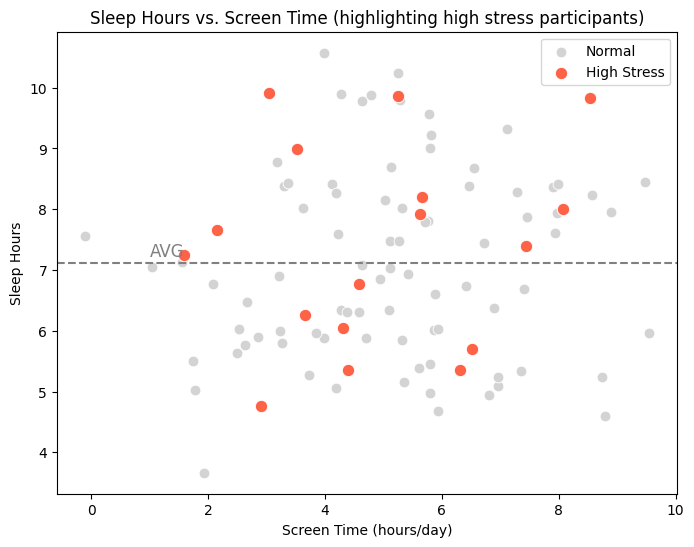

In [14]:
# Simulate some data
np.random.seed(0)
num_points = 100
screen_time = np.random.normal(5, 2, num_points)  # hours
sleep_hours = np.random.normal(7, 1.5, num_points)
stress_level = np.random.choice([0,1], size=num_points, p=[0.8,0.2])  # 1 = high stress

df_sim = pd.DataFrame({
    "ScreenTime": screen_time,
    "SleepHours": sleep_hours,
    "HighStress": stress_level
})

# Create plot
plt.figure(figsize=(8,6))

# Plot all points in gray
sns.scatterplot(
    x="ScreenTime",
    y="SleepHours",
    data=df_sim[df_sim.HighStress==0],
    color="lightgray",
    s=60,
    label="Normal"
)

# Highlight high stress points
sns.scatterplot(
    x="ScreenTime",
    y="SleepHours",
    data=df_sim[df_sim.HighStress==1],
    color="tomato",
    s=80,
    label="High Stress"
)

# Optional: add average line or annotation (like Storytelling With Data style)
plt.axhline(y=df_sim["SleepHours"].mean(), linestyle="--", color="gray", linewidth=1.5)
plt.text(1, df_sim["SleepHours"].mean()+0.1, "AVG", color="gray", fontsize=12)

# Labels and title
plt.xlabel("Screen Time (hours/day)")
plt.ylabel("Sleep Hours")
plt.title("Sleep Hours vs. Screen Time (highlighting high stress participants)")
plt.legend()
plt.show()

This style captures the look and feel of S. Knaflic’s charts in Chapter 2: highlighting key data while keeping the rest in the background.The gray points are for context, with high stress participants standing out for emphasis. The annotation on the average line shows that it is a reference point relating to the average scores. The simple clean layout has minimal grid, clear labels, and focuses on key insight.

